In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
import matplotlib.pyplot as plt

In [2]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly)

In [3]:
rng = np.random.default_rng (10)
x1 = rng.uniform (0, 1, size =100)
x2 = 0.5 * x1 + rng.normal(size =100) / 10
y = 2 + 2 * x1 + 0.3 * x2 + rng.normal(size =100)

In [4]:
np.corrcoef(x1, x2)

array([[1.       , 0.7723245],
       [0.7723245, 1.       ]])

Text(0.5, 1.0, 'Scatter plot showing correlation between x1 and x2')

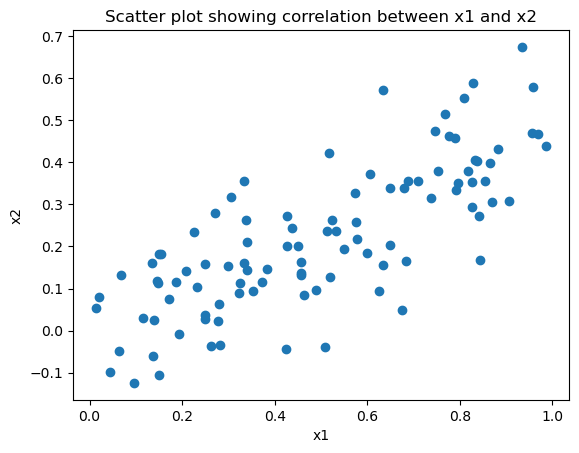

In [5]:
plt.scatter(x1, x2)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Scatter plot showing correlation between x1 and x2")

In [6]:
df = pd.DataFrame({"x1" : x1, "x2" : x2})
X = MS(["x1", "x2"]).fit_transform(df)
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,1.9579,0.190,10.319,0.000
x1,1.6154,0.527,3.065,0.003
x2,0.9428,0.831,1.134,0.259


(c) We can reject the null hypothesis for beta1 but we can't reject the null hypothesis for the beta2

In [7]:
model2 = sm.OLS(y, x1)
results2 = model2.fit()
summarize(results2)

,coef,std err,t,P>|t|
x1,5.0887,0.231,22.075,0.0


(d) We can reject the null hypothesis.

In [8]:
model3 = sm.OLS(y, x2)
results3 = model3.fit()
summarize(results3)

,coef,std err,t,P>|t|
x1,9.4697,0.615,15.406,0.0


(e) We can reject the null hypothesis.

(f) Yes (c) and (e) contradict each other it is because x2 is also dependent on the x1 so when we take x1 and x2 into the consideration, x2 isn't relevant.

In [9]:
x1 = np.concatenate ([x1 , [0.1]])
x2 = np.concatenate ([x2 , [0.8]])
y = np.concatenate ([y, [6]])

In [10]:
np.corrcoef(x1, x2)

array([[1.        , 0.67891508],
       [0.67891508, 1.        ]])

Text(0.5, 1.0, 'Scatter plot showing correlation between x1 and x2')

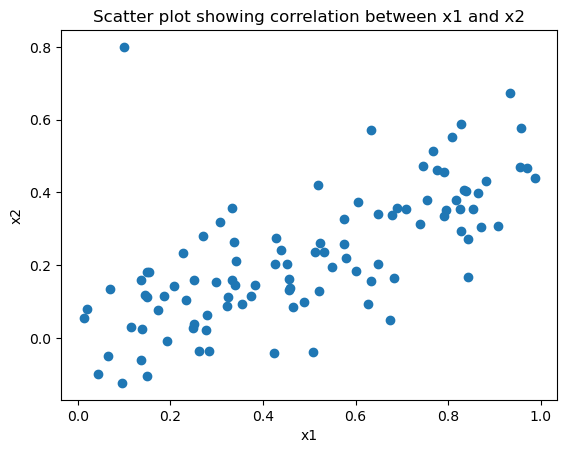

In [11]:
plt.scatter(x1, x2)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Scatter plot showing correlation between x1 and x2")

In [12]:
df = pd.DataFrame({"x1" : x1, "x2" : x2})
X = MS(["x1", "x2"]).fit_transform(df)
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,2.0618,0.192,10.720,0.000
x1,0.8575,0.466,1.838,0.069
x2,2.2663,0.705,3.216,0.002


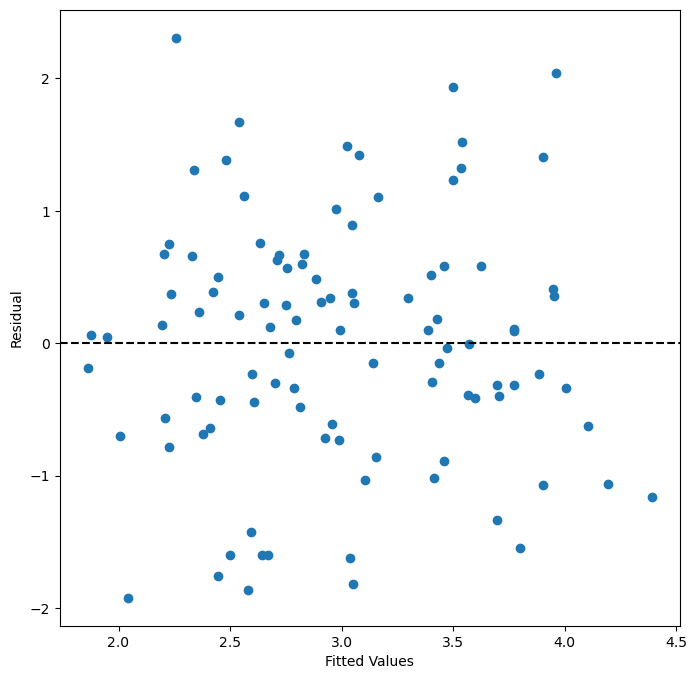

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--')

np.int64(100)

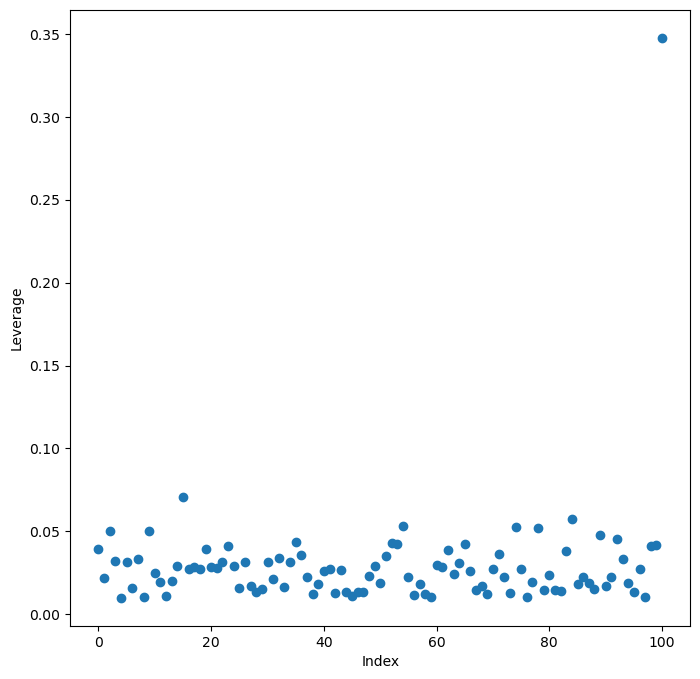

In [14]:
infl = results.get_influence()
fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

In [15]:
(results.resid).iloc[-1]

np.float64(2.039395468251756)

In [16]:
(infl.hat_matrix_diag)[-1]

np.float64(0.34767161961426646)

In [17]:
threshold_infl = 3/100
print(f"Threshold Influence is : {threshold_infl}")

Threshold Influence is : 0.03


From the above two figures it is clear that for the extra point is both an outlier and a high leverage point.

In [18]:
model2 = sm.OLS(y, x1)
results2 = model2.fit()
summarize(results2)

,coef,std err,t,P>|t|
x1,5.1059,0.249,20.496,0.0


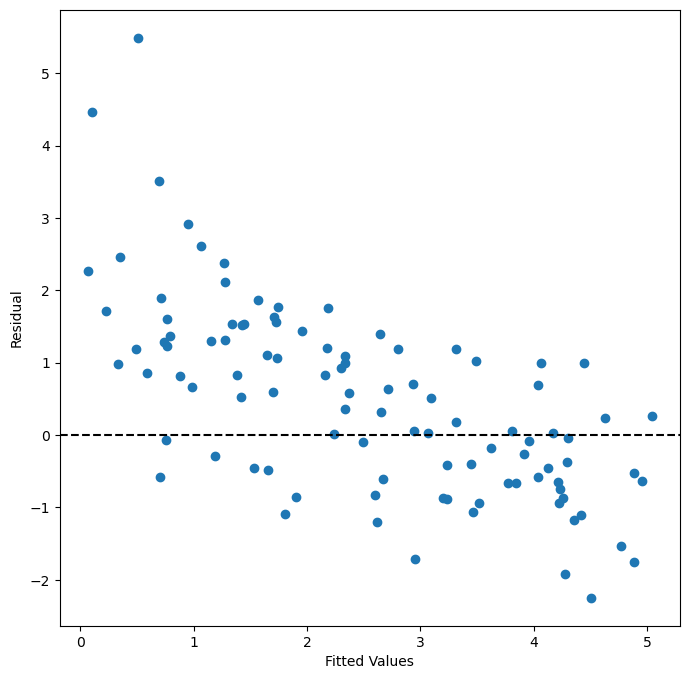

In [19]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(results2.fittedvalues, results2.resid)
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--')

np.int64(100)

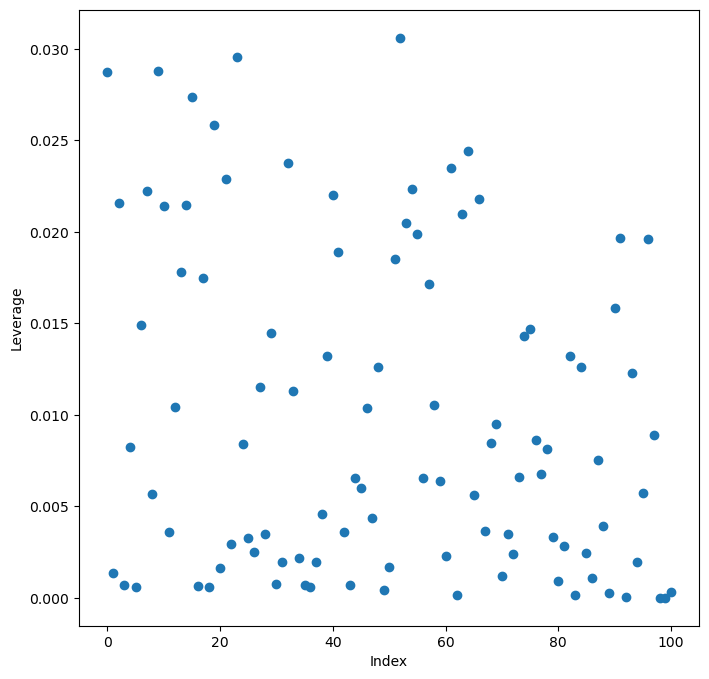

In [20]:
infl2 = results2.get_influence()
fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(np.arange(X.shape[0]), infl2.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

In [21]:
(results2.resid)[-1]

np.float64(5.489407079559532)

In [22]:
(infl2.hat_matrix_diag)[-1]

np.float64(0.00031410304917073897)

In [23]:
threshold_infl = 3/100 # (p+1)/n , p = no. of predictors, n = no. of data points
print(f"Threshold Influence is : {threshold_infl}")

Threshold Influence is : 0.03


So, we can see that for the model 2 (only with x1) the point is an outlier (since residual > 2) but not a high influence point

In [24]:
model3 = sm.OLS(y, x2)
results3 = model3.fit()
summarize(results3)

,coef,std err,t,P>|t|
x1,9.3204,0.59,15.79,0.0


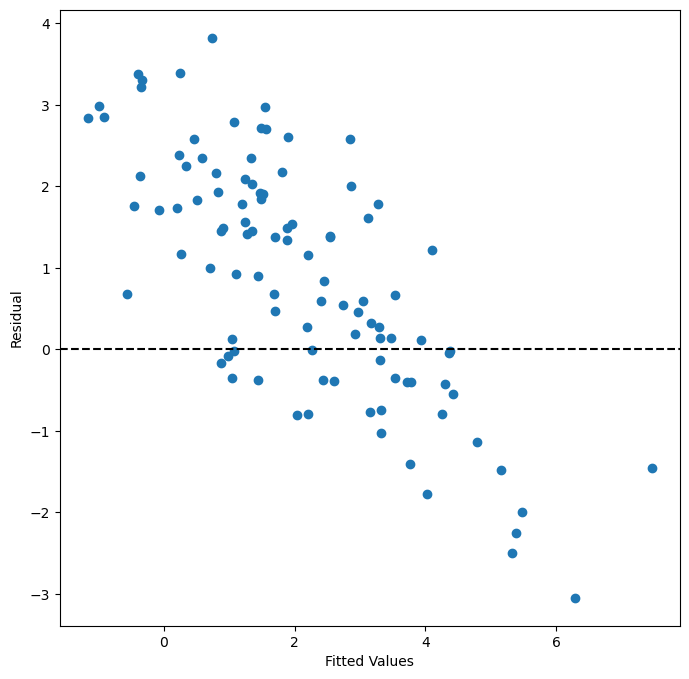

In [25]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(results3.fittedvalues, results3.resid)
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--')

np.int64(100)

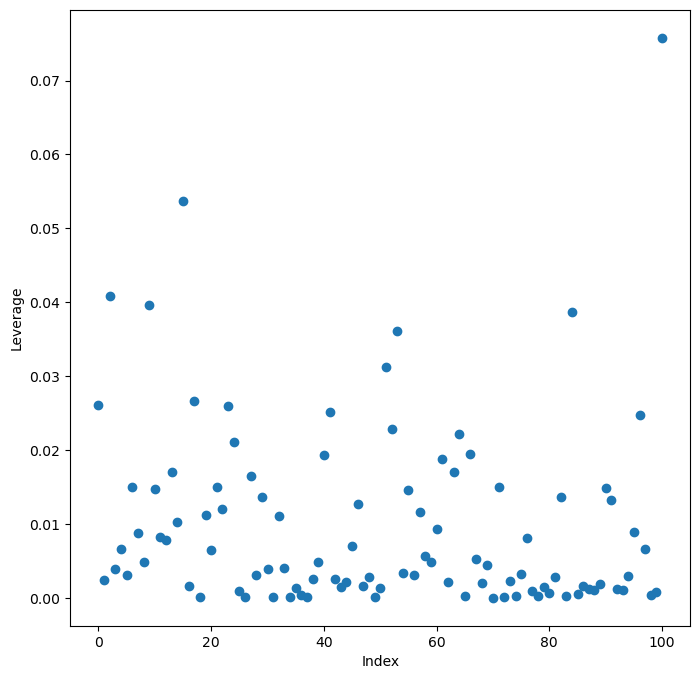

In [26]:
infl3 = results3.get_influence()
fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(np.arange(X.shape[0]), infl3.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

In [27]:
(results3.resid)[-1]

np.float64(-1.4563401495650403)

In [28]:
(infl3.hat_matrix_diag)[-1]

np.float64(0.07580608861211803)

In [29]:
threshold_infl = 3/100
print(f"Threshold Influence is : {threshold_infl}")

Threshold Influence is : 0.03


The point is not an outlier but a high leverage point.